User Behavior Anomaly Detection using Isolation Forest


Dataset:
       UserID  Daily_Logins  Failed_Password_Attempts  Session_Duration_Min  \
0  USER-6000             3                         0                  27.1   
1  USER-6001             3                         0                 276.5   
2  USER-6002             2                         0                  35.4   
3  USER-6003             5                         0                  35.7   
4  USER-6004             4                         0                  27.2   

   Data_Download_MB  Off_Hours_Activity_Pct  Unique_IP_Count  
0              23.5                     7.2                1  
1            2099.9                    84.4                3  
2              47.7                     4.9                3  
3              47.9                    14.4                1  
4              39.6                    11.6                1  

Dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column     

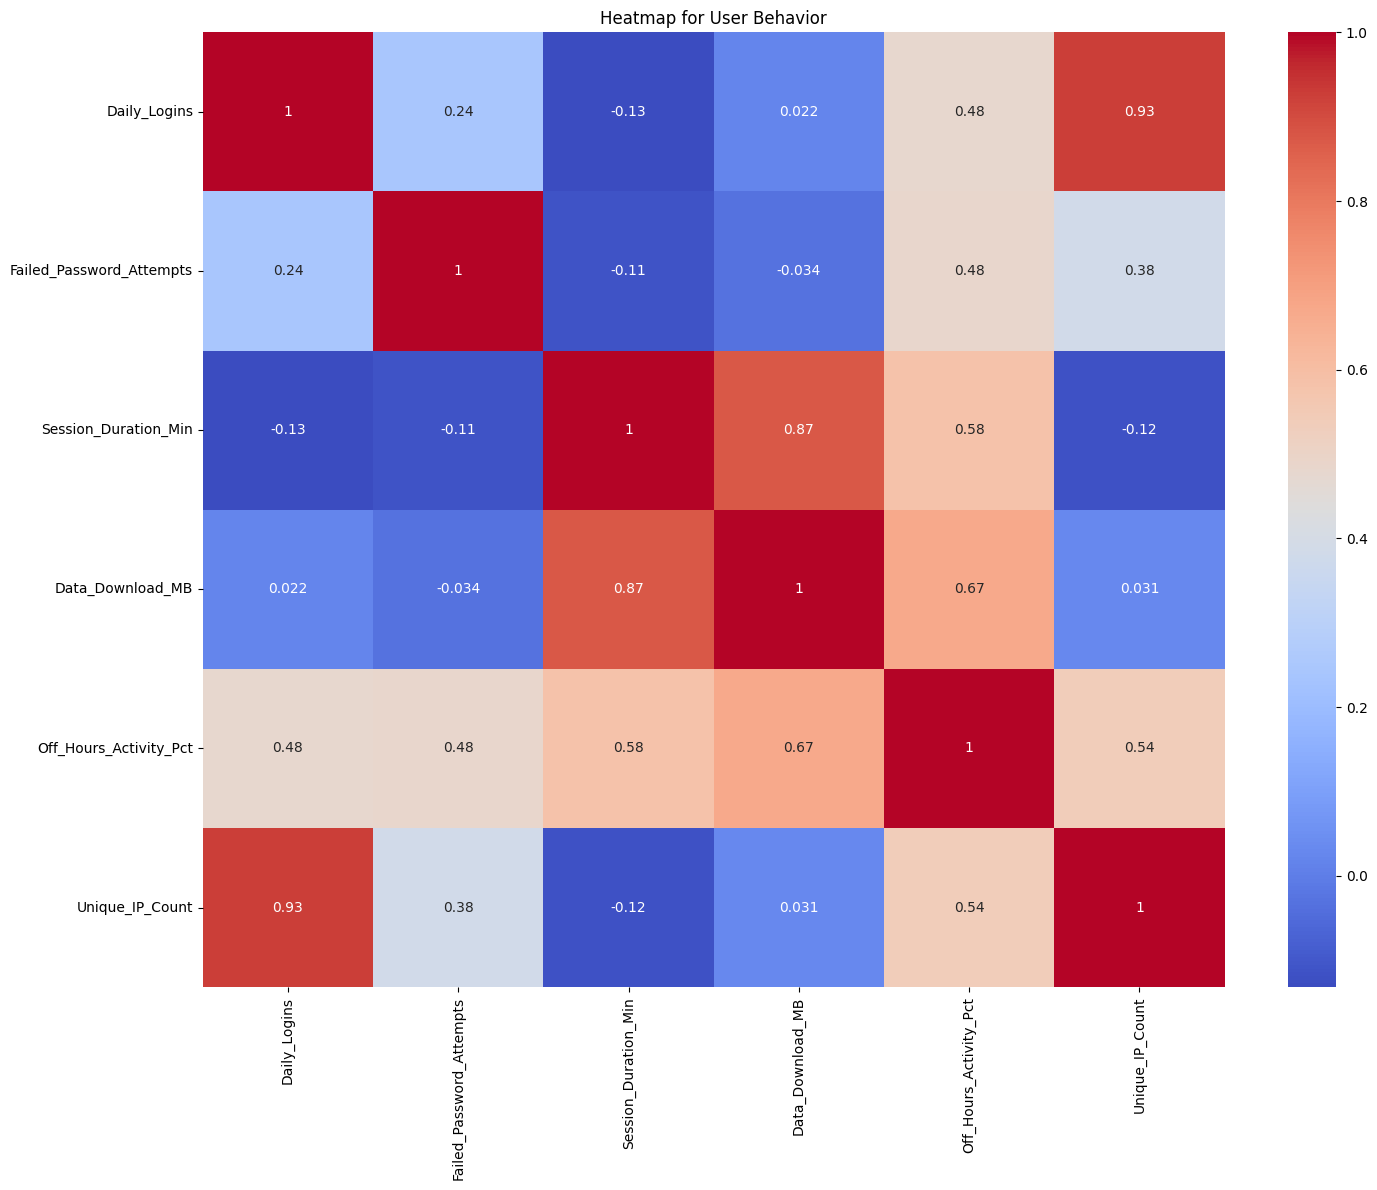

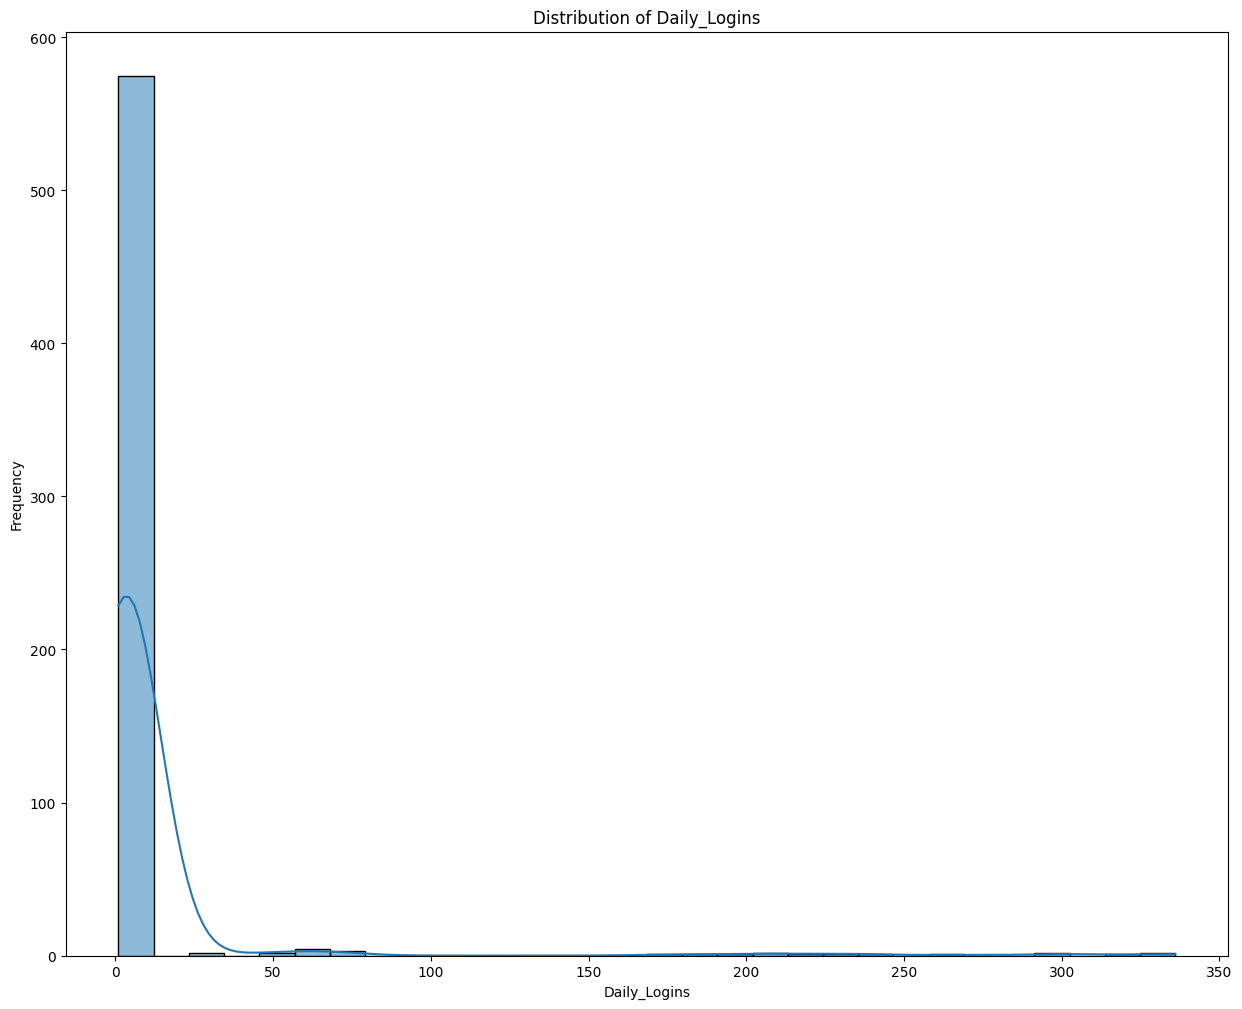

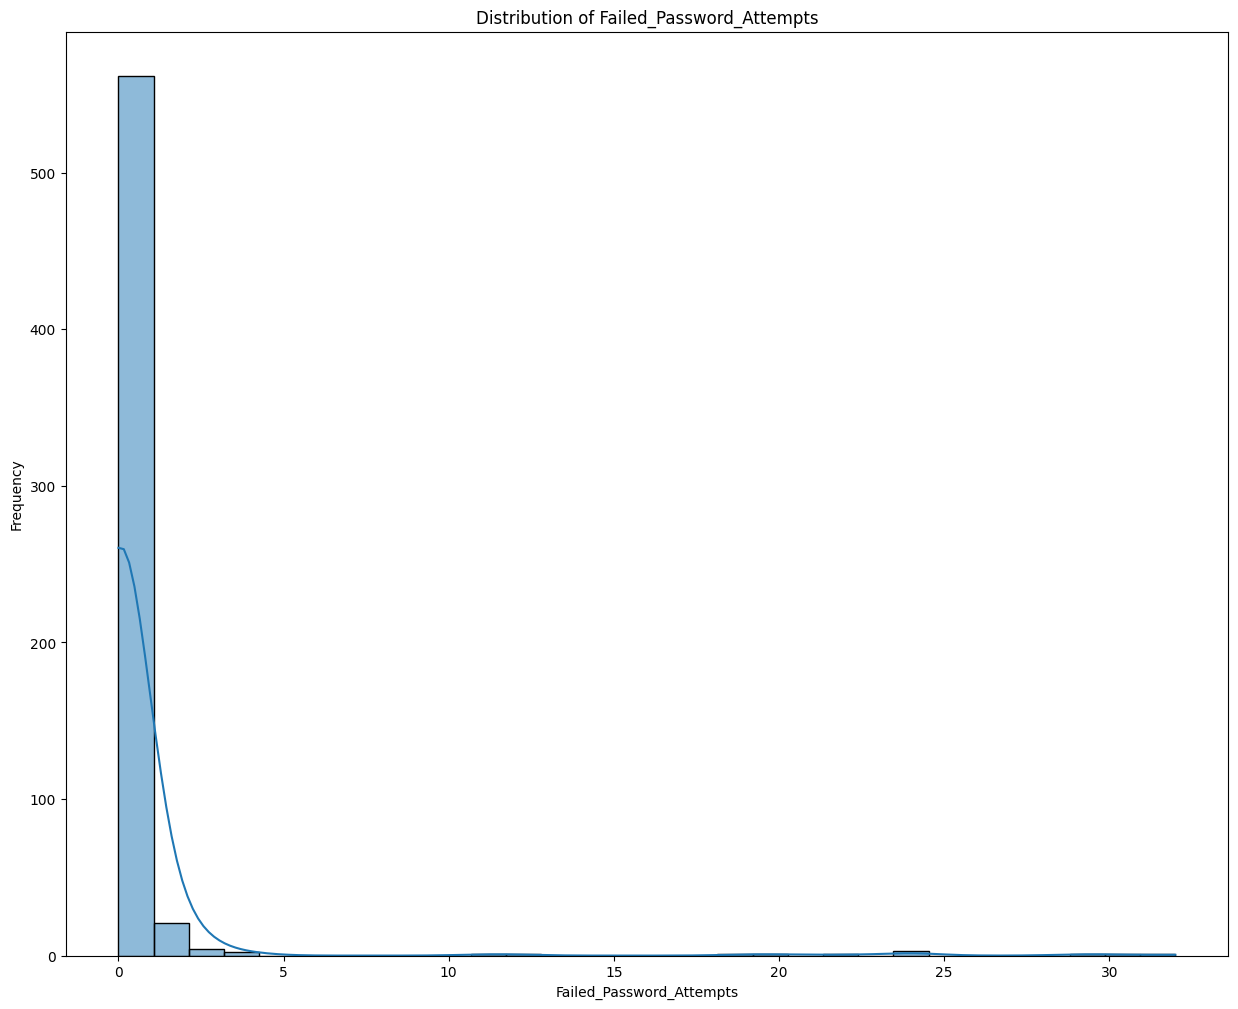

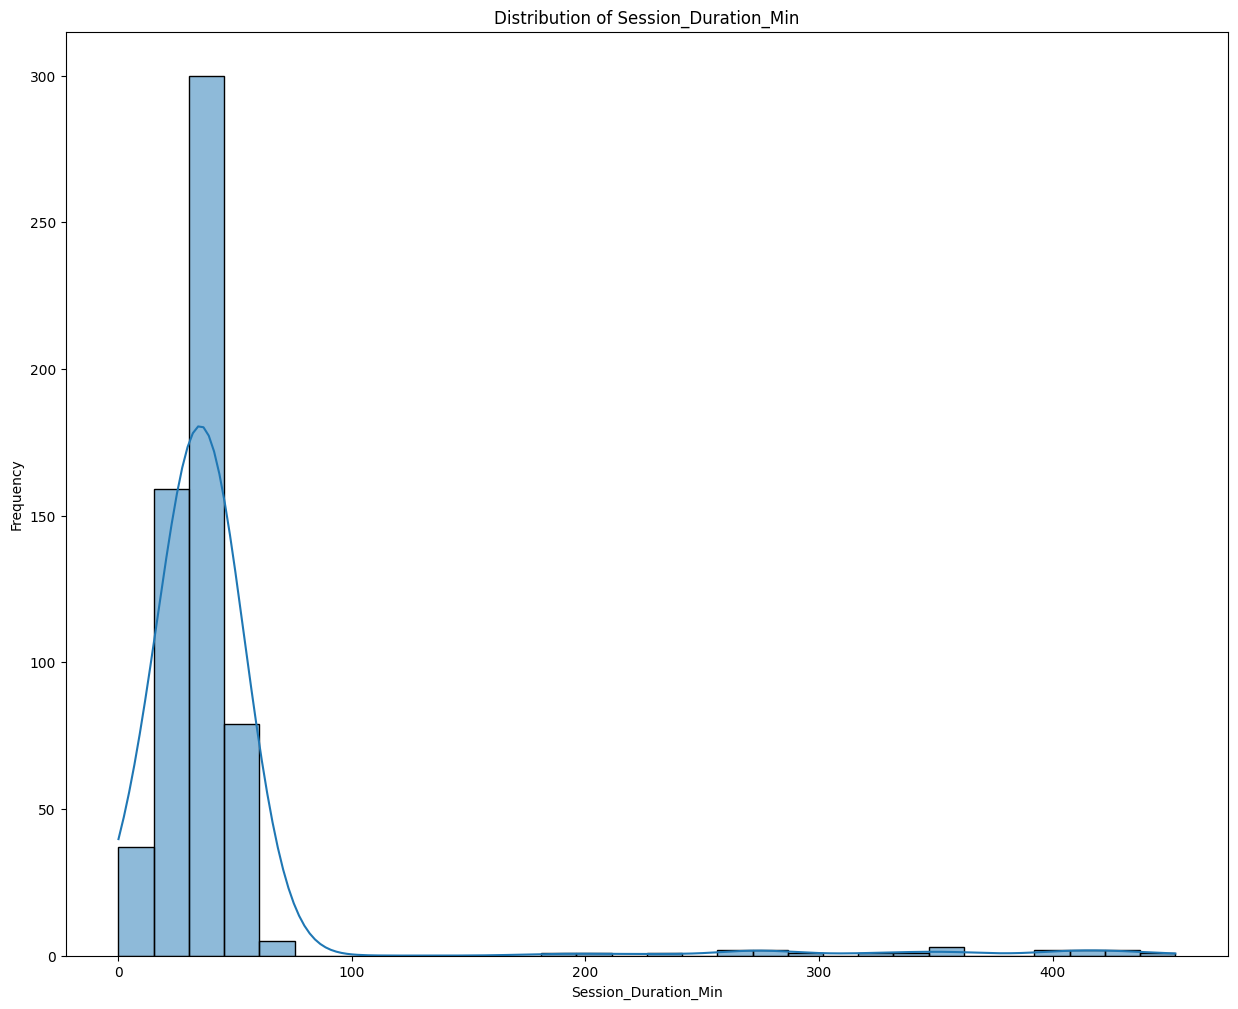

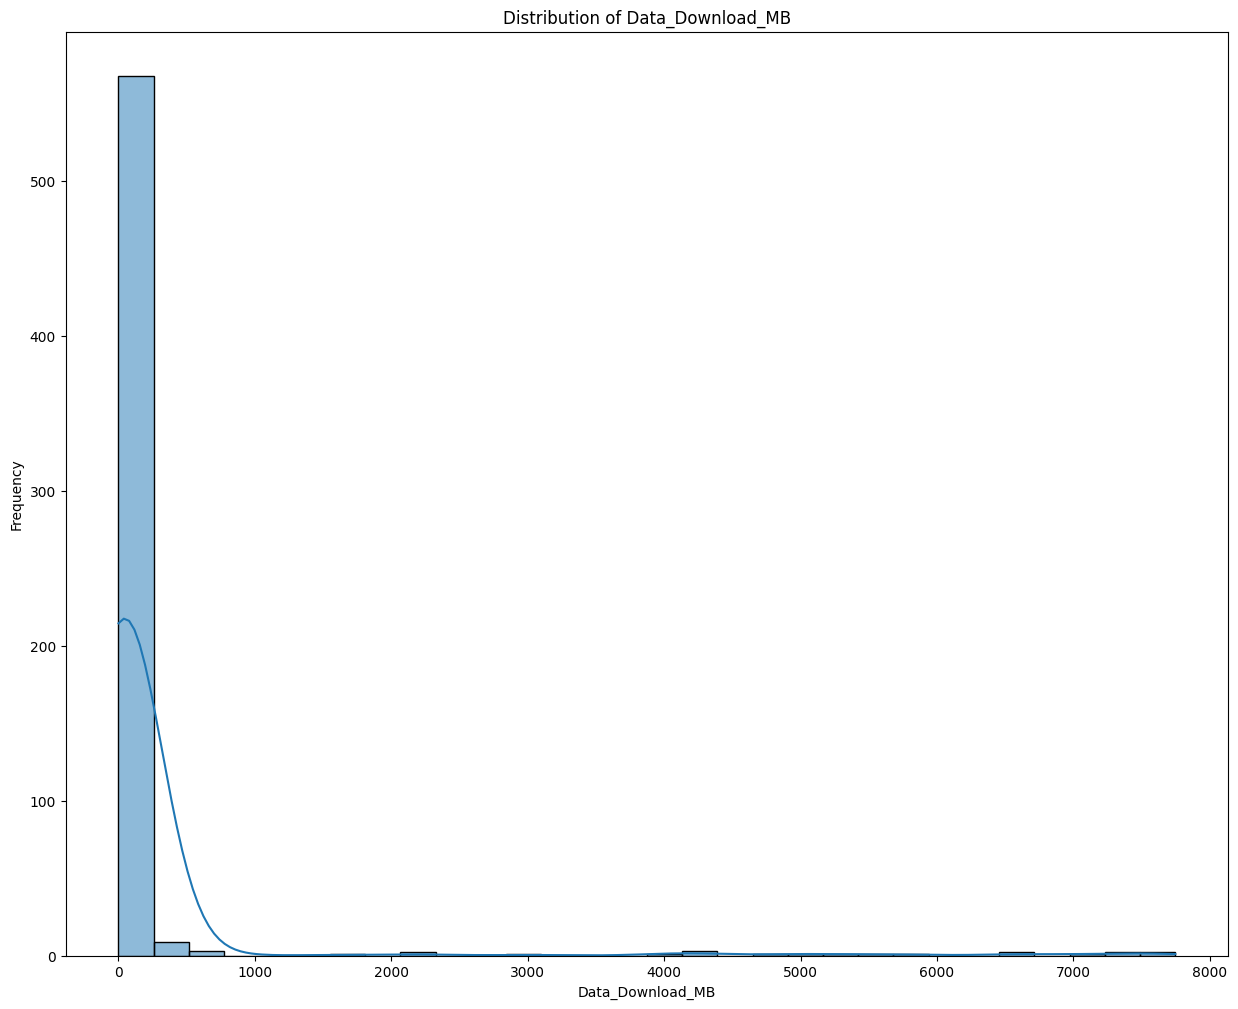

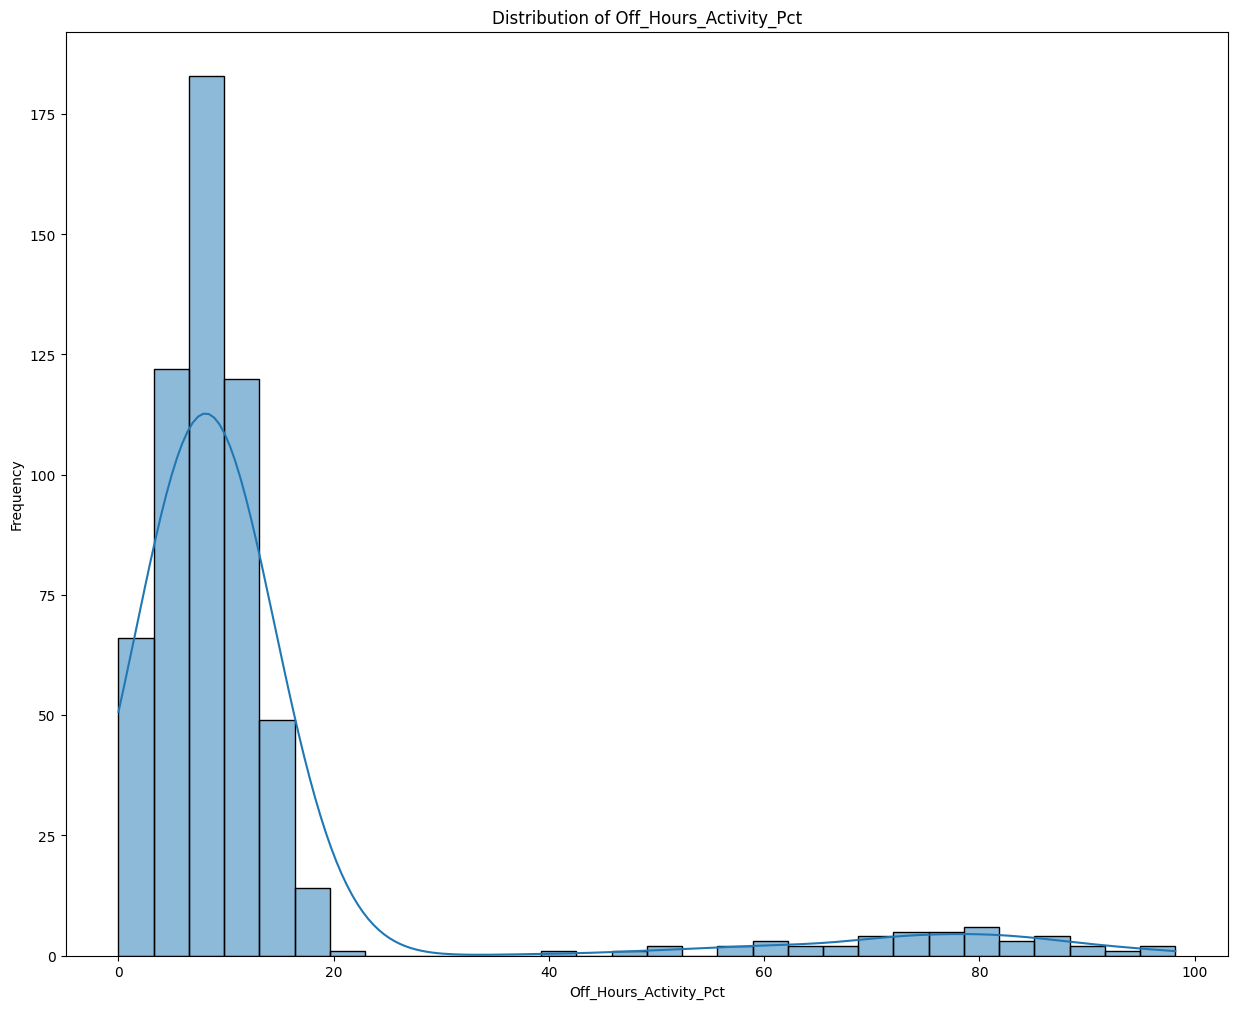

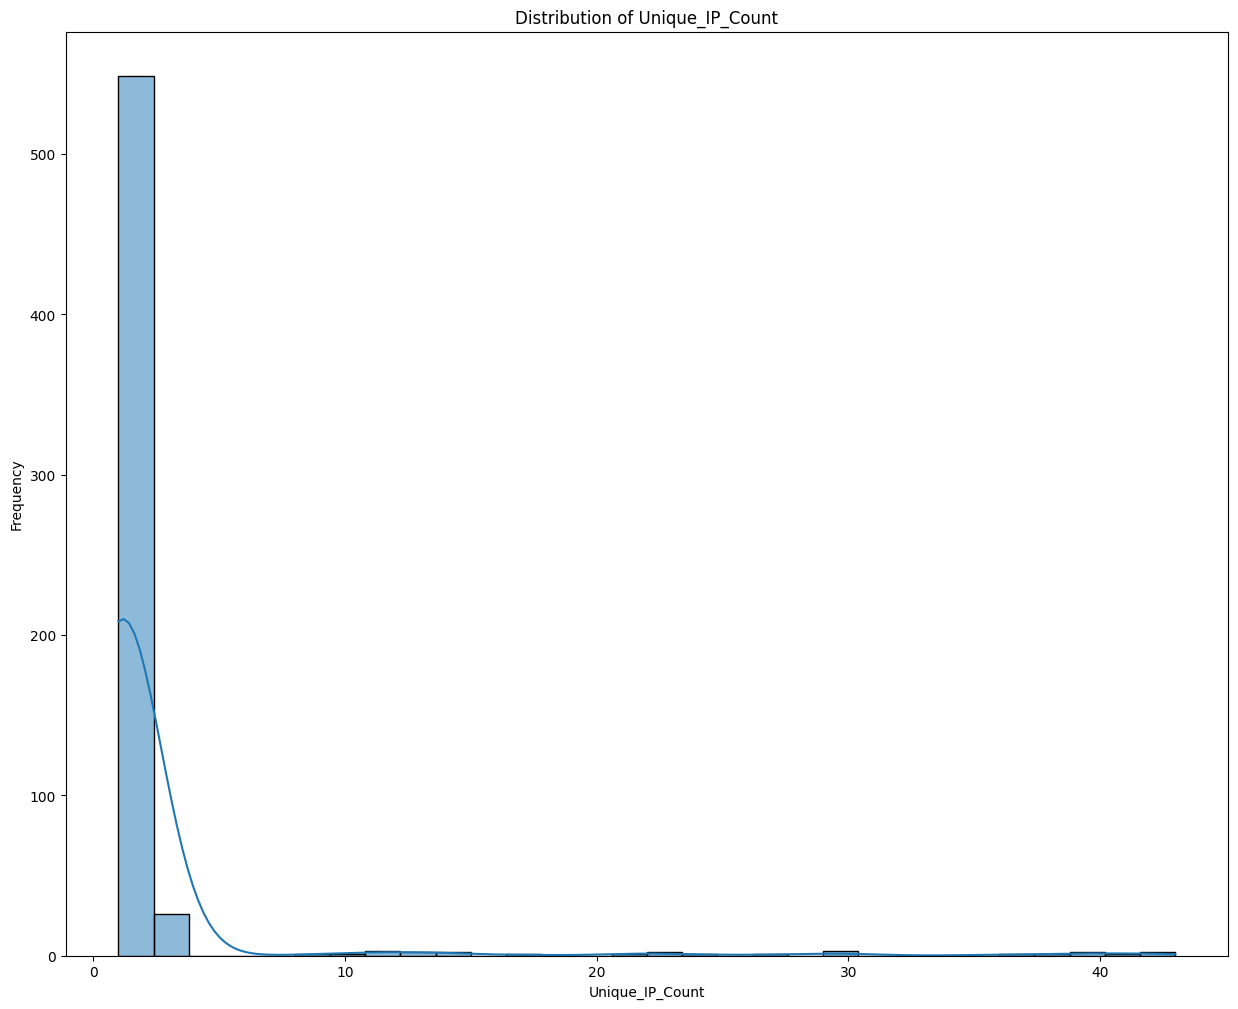


Rule-Based Reference Label Distribution:
Reference_Label
0    555
1     45
Name: count, dtype: int64
Reference_Label
0    92.5
1     7.5
Name: proportion, dtype: float64


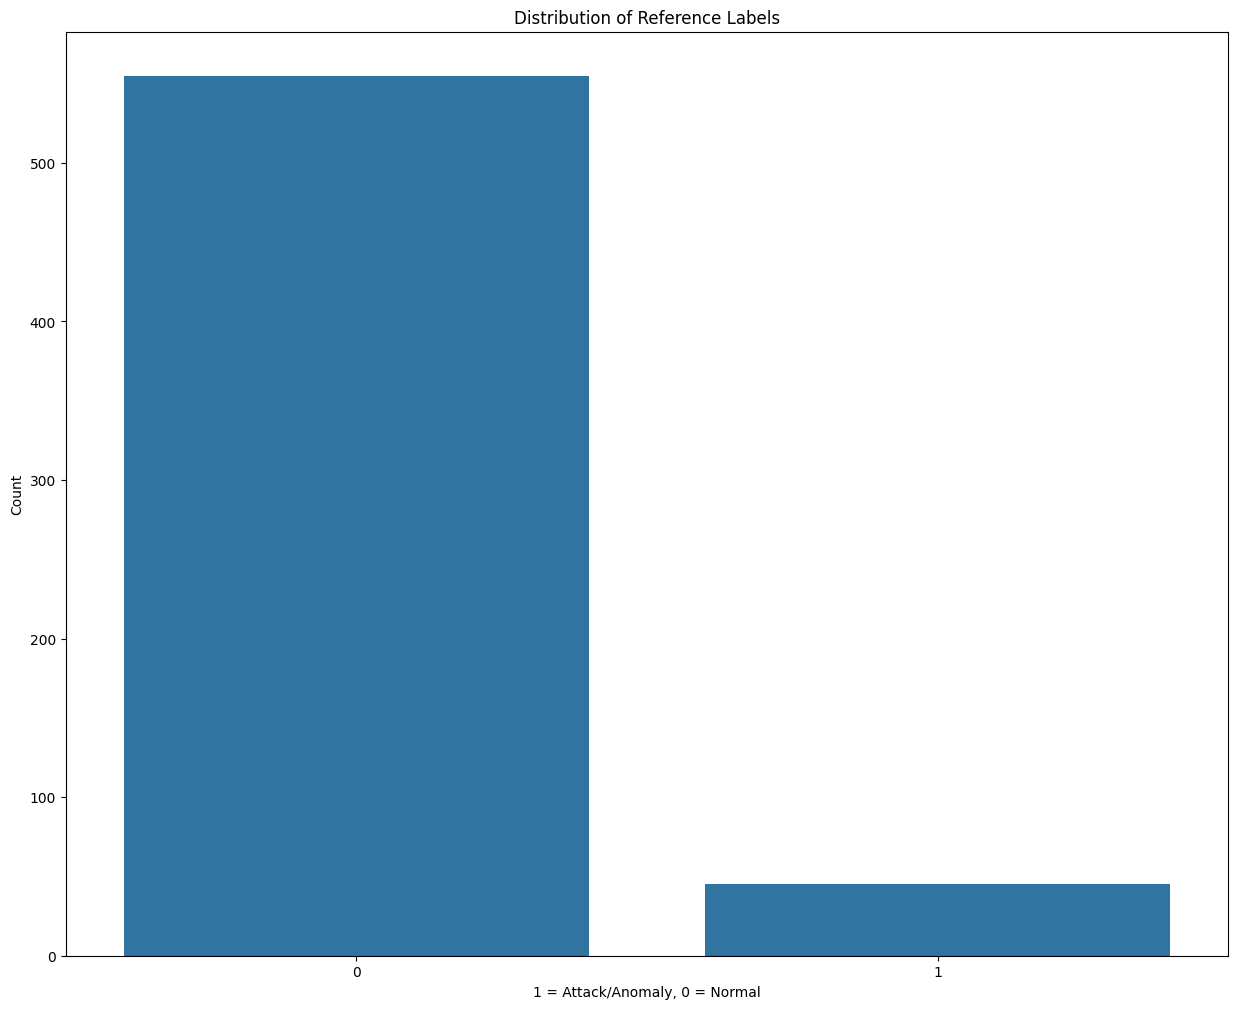


Selected Features:
['Daily_Logins', 'Failed_Password_Attempts', 'Session_Duration_Min', 'Data_Download_MB', 'Off_Hours_Activity_Pct', 'Unique_IP_Count']

X Shape:

Base Model Prediction Distribution:
Base_Prediction
 1    570
-1     30
Name: count, dtype: int64
Base_Prediction
 1    95.0
-1     5.0
Name: proportion, dtype: float64


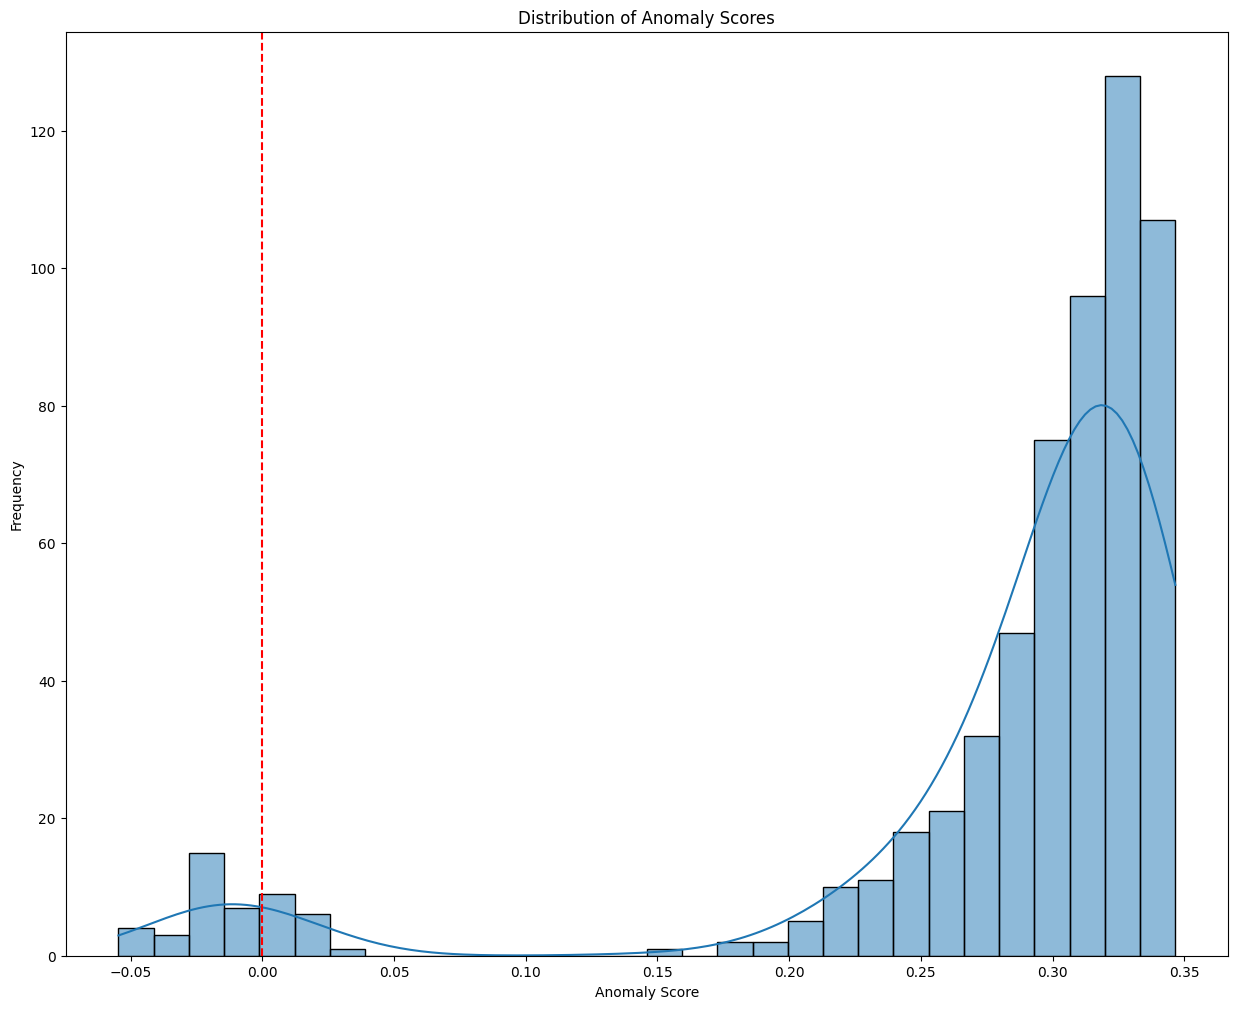


========== BASE MODEL METRICS ==========
Accuracy : 0.975
Precision: 1.0
Recall   : 0.6666666666666666
F1 Score : 0.8

Base Classification Report
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.99       555
      Attack       1.00      0.67      0.80        45

    accuracy                           0.97       600
   macro avg       0.99      0.83      0.89       600
weighted avg       0.98      0.97      0.97       600


Confusion Matrix
[[555   0]
 [ 15  30]]

Base Model Confusion Matrix

Base Model Confusion Matrix
[[555   0]
 [ 15  30]]


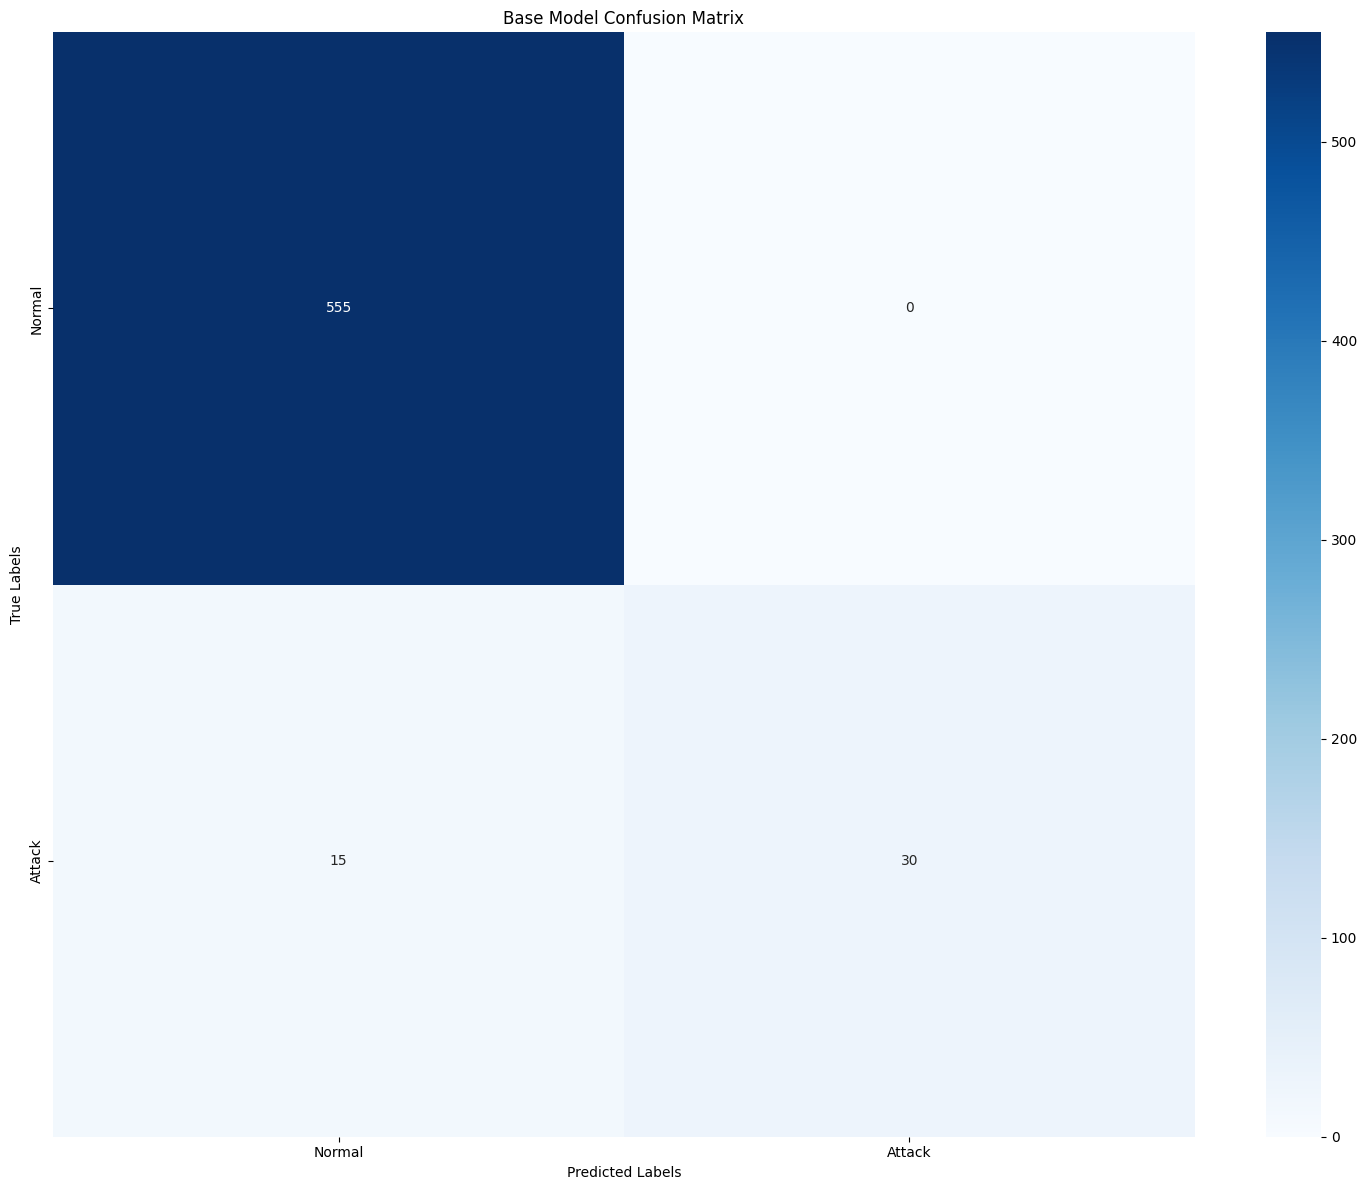


========== PARAMETER TUNING RESULTS ==========
   n_estimators max_samples  contamination  max_features  bootstrap  n_jobs  \
4           300         1.0           0.10           1.0      False      -1   
0           100        auto           0.05           1.0      False      -1   
1           200        auto           0.05           1.0      False      -1   
2           300        auto           0.05           1.0      False      -1   
3           200        auto           0.05           1.0      False      -1   

   Accuracy  Precision    Recall  F1 Score  
4     0.975       0.75  1.000000  0.857143  
0     0.975       1.00  0.666667  0.800000  
1     0.975       1.00  0.666667  0.800000  
2     0.975       1.00  0.666667  0.800000  
3     0.975       1.00  0.666667  0.800000  

========== BEST PARAMETERS ==========
{'n_estimators': 300, 'max_samples': 1.0, 'contamination': 0.1, 'max_features': 1.0, 'bootstrap': False, 'n_jobs': -1}

Best F1 Score: 0.8571428571428571

Final Anomaly

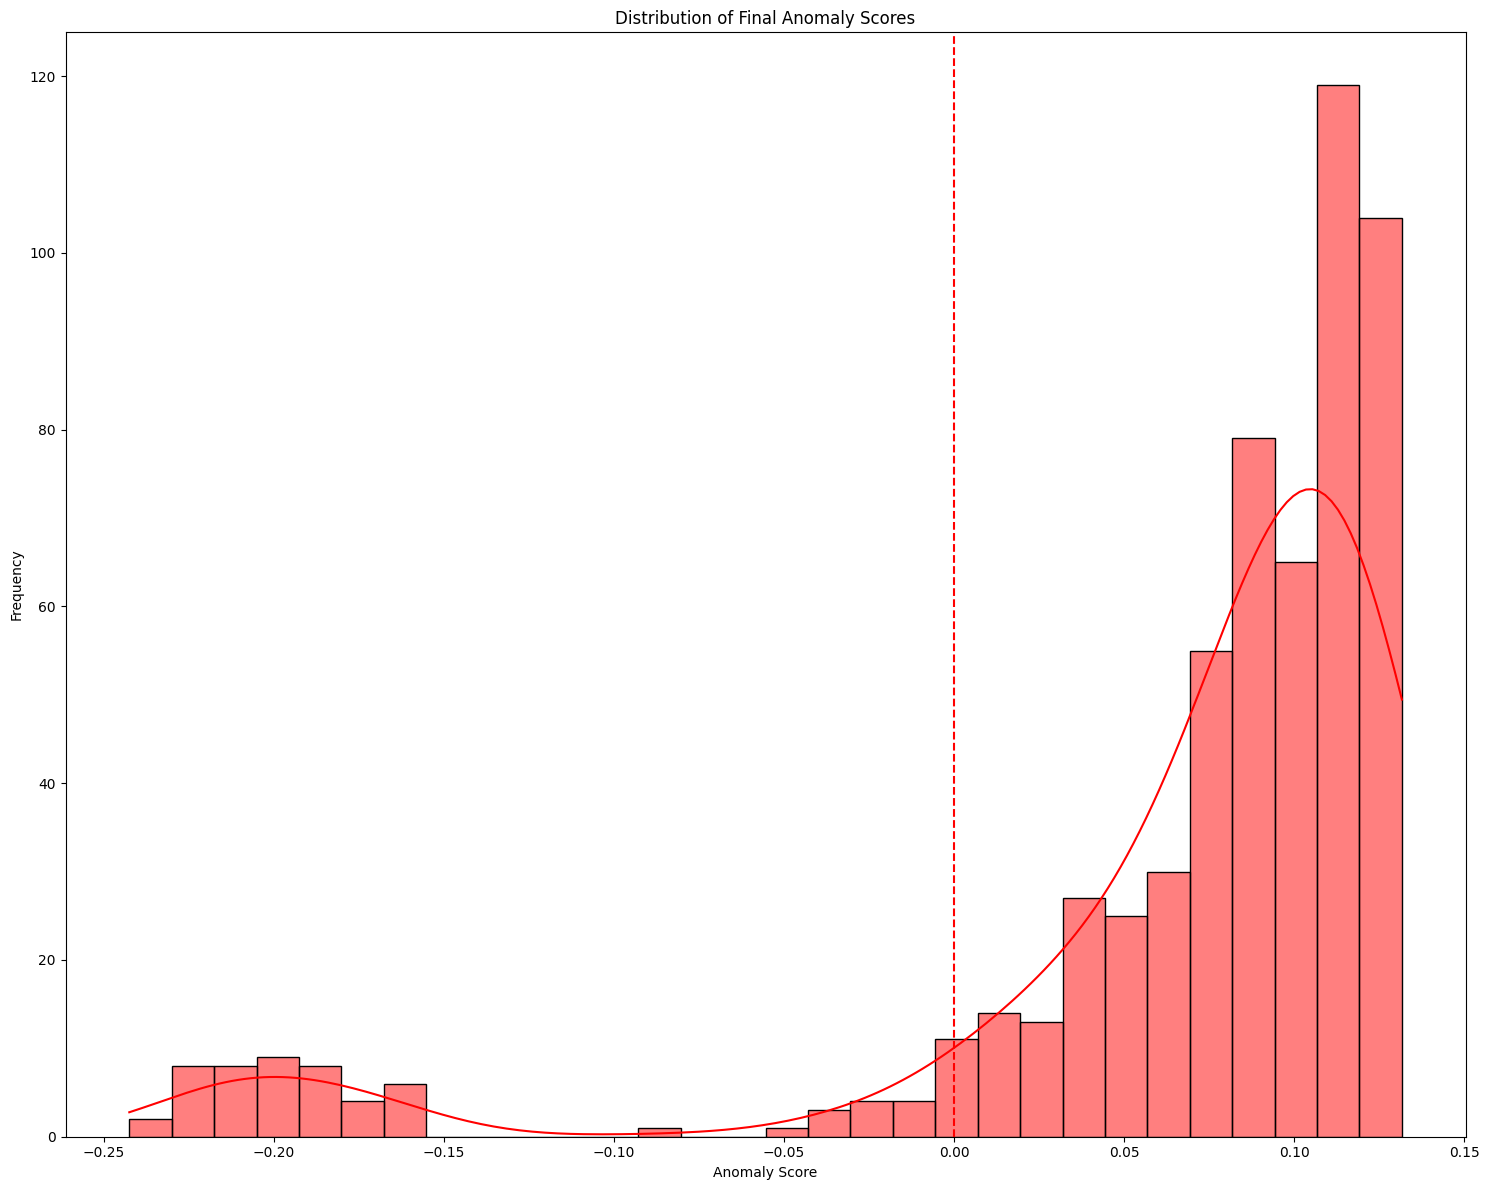

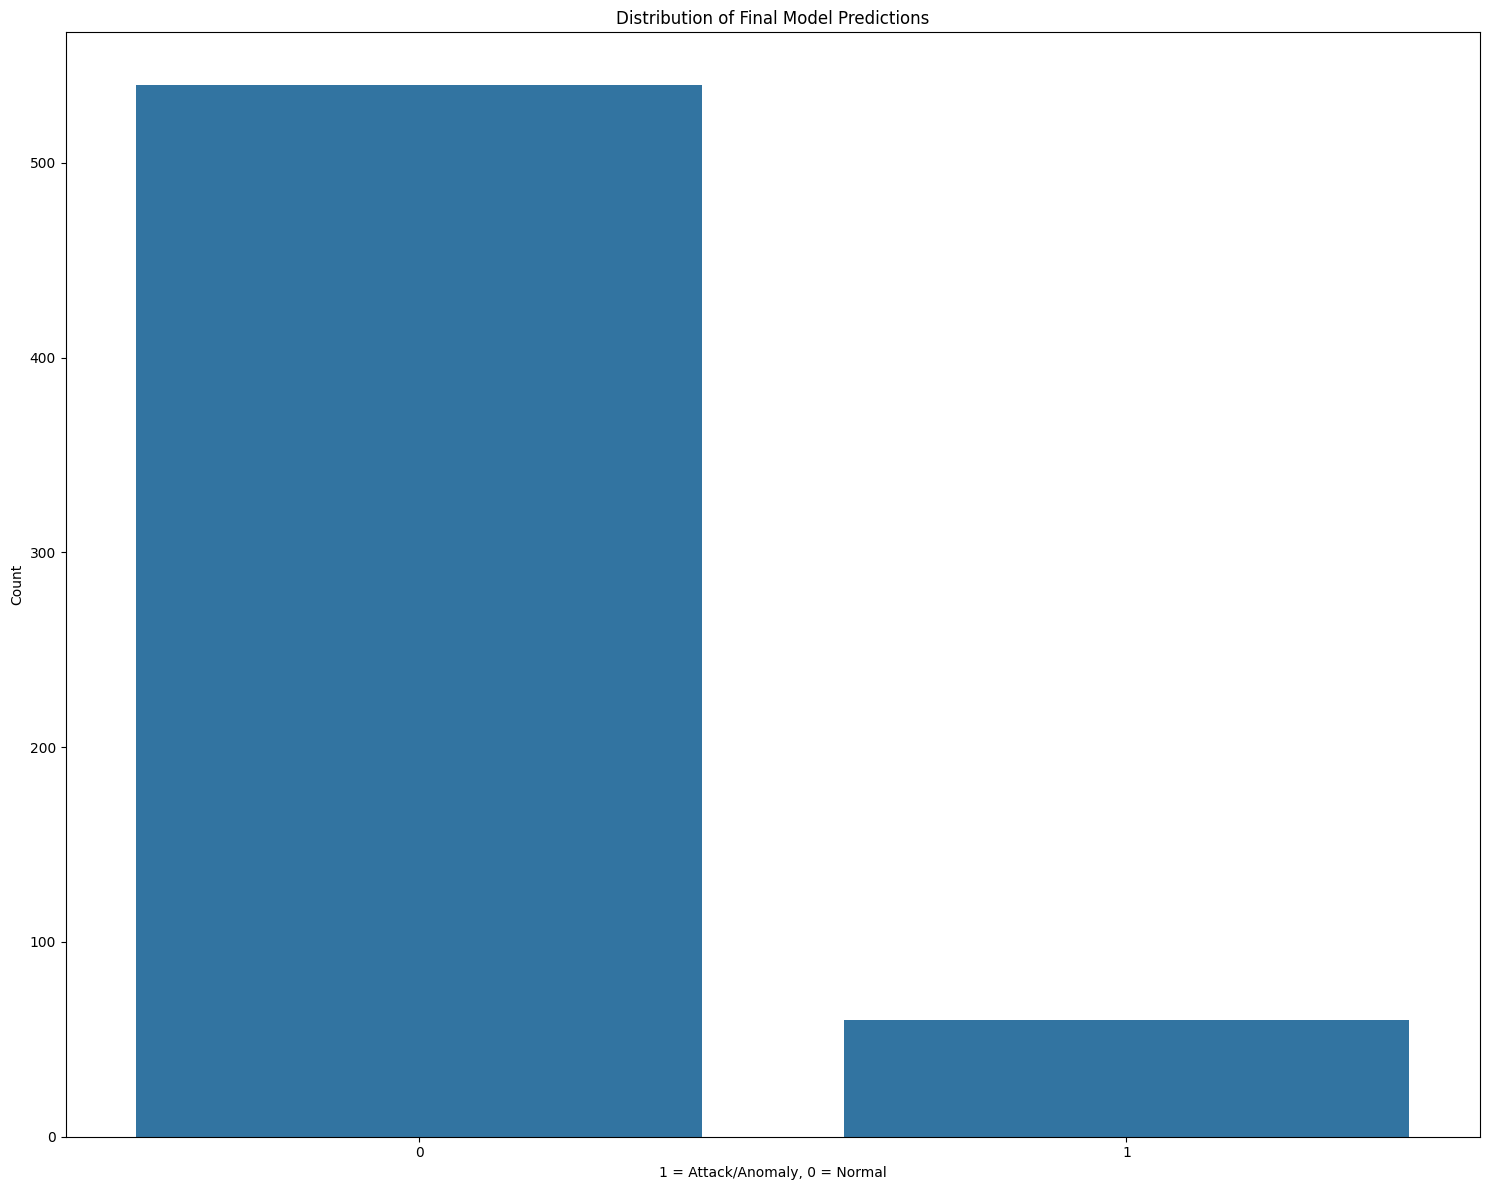


Final Model Confusion Matrix
[[540  15]
 [  0  45]]

FINAL MODEL EVALUATION

Confusion Matrix:
[[540  15]
 [  0  45]]

Accuracy : 0.975
Precision: 0.75
Recall : 1.0
F1 Score : 0.8571428571428571

Final Classification Report
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99       555
      Attack       0.75      1.00      0.86        45

    accuracy                           0.97       600
   macro avg       0.88      0.99      0.92       600
weighted avg       0.98      0.97      0.98       600



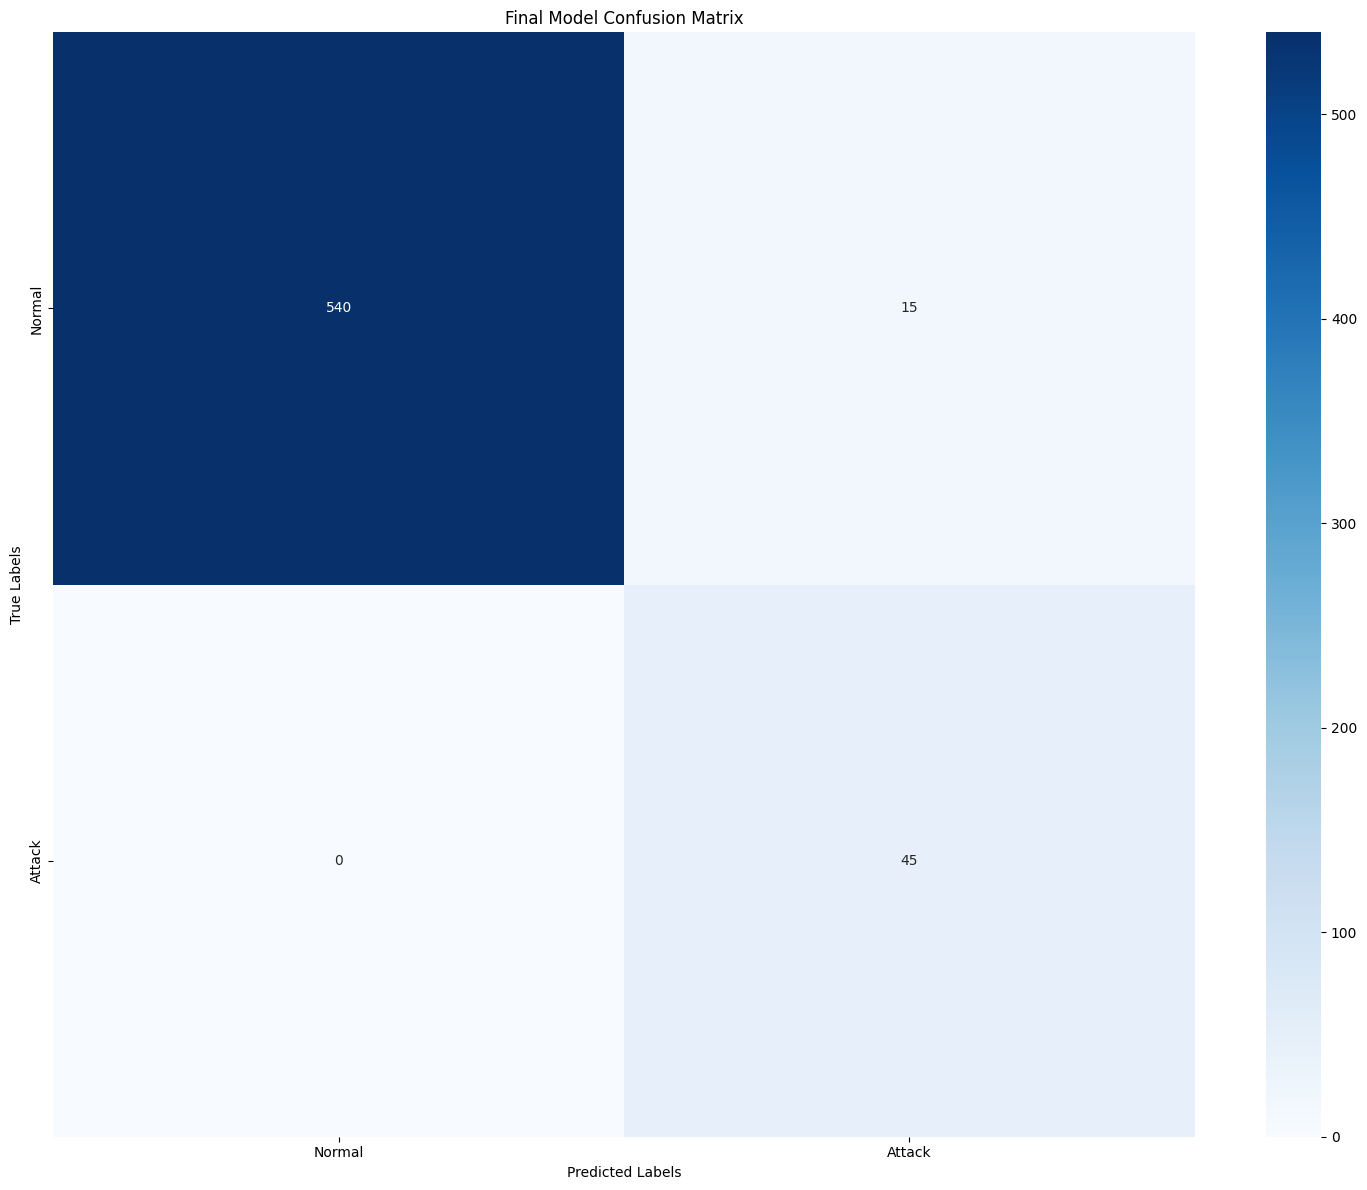


DETECTED ANOMALIES
     Daily_Logins  Failed_Password_Attempts  Session_Duration_Min  \
1               3                         0                 276.5   
11              5                         0                 347.0   
20              1                         1                  35.2   
33              2                         0                 273.4   
34              4                         0                 233.4   
50              3                         0                 411.3   
69              4                         0                 333.8   
85              1                         2                  30.9   
107             4                         1                  28.1   
134           266                         3                   0.9   
139            57                        22                   4.0   
140             3                         0                 397.4   
154            58                        29                   1.1   
185           

In [20]:
# Step 1: Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    recall_score,
    precision_score
)


# Step 2: Import CSV Dataset
df = pd.read_csv("/content/user_behavior_telemetry.csv")

print("\nDataset:\n", df.head())
print("\nDataset information\n")
df.info()
print("\nStatistical summary\n", df.describe())
print("\nMissing values check:\n", df.isnull().sum())

# Step 4: Handle Infinite Values
num_cols = df.select_dtypes(include=np.number).columns

print("\nInfinite Values:")

df.replace(
    [-np.inf, np.inf],
    np.nan,
    inplace=True
)

df.dropna(inplace=True)

# Step 5: Exploratory Data Analysis — EDA

numerical_cols = df.select_dtypes(include=np.number).columns

# Correlation Heatmap

plt.figure(figsize=(15,12))
sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Heatmap for User Behavior")
plt.tight_layout()
plt.show()

# Important features distributions visualize
features_for_plot = [
        "Daily_Logins",
        "Failed_Password_Attempts",
        "Session_Duration_Min",
        "Data_Download_MB",
        "Off_Hours_Activity_Pct",
        "Unique_IP_Count"
        ]

for feature in features_for_plot:
  plt.figure(figsize=(15,12))

  sns.histplot(
      df[feature],
      bins=30,
      kde=True
  )

  plt.title(f"Distribution of {feature}")
  plt.xlabel(feature)
  plt.ylabel("Frequency")
  plt.savefig(f"{feature}_distribution.png")
  plt.show()


# Step 6: Create Rule-Based Reference Labels

def create_reference_label(row,stats):
  for features in stats:
    mean, std = stats[features]
    lower,upper = mean - 3*std, mean + 3*std
    if row[features] < lower or row[features] > upper:
      return 1 # Attack
  return 0 # Normal


# Calculate Mean & Std for Each Feature
stats ={
    col: (df[col].mean(), df[col].std())
    for col in features_for_plot
}

# Apply Rule

df["Reference_Label"] = df.apply(
    lambda row: create_reference_label(row,stats),axis=1
)

# Step 7: Analyze Reference Labels
print("\nRule-Based Reference Label Distribution:")
print(df["Reference_Label"].value_counts())
print(df["Reference_Label"].value_counts(normalize=True).mul(100))

plt.figure(figsize=(15,12))
sns.countplot(data=df, x="Reference_Label")
plt.title("Distribution of Reference Labels")
plt.xlabel("1 = Attack/Anomaly, 0 = Normal")
plt.ylabel("Count")
plt.savefig("reference_label_distribution.png")
plt.show()

# Step 8: Feature Selection

features_df = [
    "Daily_Logins",
    "Failed_Password_Attempts",
    "Session_Duration_Min",
    "Data_Download_MB",
    "Off_Hours_Activity_Pct",
    "Unique_IP_Count"
]
X = df[features_df].copy()

print("\nSelected Features:")
print(features_df)

print("\nX Shape:")

# Step 9: Feature Scaling
scaler = StandardScaler()
X_Scaled = scaler.fit_transform(X)

# Step 10: Base Model Training
base_model = IsolationForest(
    n_estimators=200,
    max_samples="auto",
    contamination=0.05,
    random_state=42,
    bootstrap=False,
    n_jobs=-1
)

base_prediction = base_model.fit_predict(X_Scaled)
df["Base_Prediction"] = base_prediction
df["Base_Model_Binary"] = pd.Series(
    base_prediction).map({
        1:0,
        -1:1
    })

print("\nBase Model Prediction Distribution:")
print(df["Base_Prediction"].value_counts())
print(df["Base_Prediction"].value_counts(normalize=True).mul(100))

#Step 11: Base Model Anomaly Score
df["Base_anomaly_Score"] = base_model.decision_function(X_Scaled)

plt.figure(figsize=(15,12))
sns.histplot(
    df["Base_anomaly_Score"],
    bins=30,
    kde=True
)
plt.axvline(
    x=0,
    color="red",
    linestyle="--"
)
plt.title("Distribution of Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.savefig("base_model_anomaly_score_distribution.png")
plt.show()

# Step 12; Base Model Evaluation

base_accuracy = accuracy_score(
    df["Reference_Label"],
    df["Base_Model_Binary"]
)

base_precision = precision_score(
    df["Reference_Label"],
    df["Base_Model_Binary"],
    zero_division=0
)

base_recall = recall_score(
    df["Reference_Label"],
    df["Base_Model_Binary"],
    zero_division=0
)

base_f1 = f1_score(
    df["Reference_Label"],
    df["Base_Model_Binary"],
    zero_division=0
)

print("\n========== BASE MODEL METRICS ==========")
print("Accuracy :", base_accuracy)
print("Precision:", base_precision)
print("Recall   :", base_recall)
print("F1 Score :", base_f1)

print("\nBase Classification Report")
print(classification_report(
    df["Reference_Label"],
    df["Base_Model_Binary"],
    target_names=["Normal","Attack"],
    zero_division=0
))

print("\nConfusion Matrix")
print(confusion_matrix(
    df["Reference_Label"],
    df["Base_Model_Binary"],
))

print("\nBase Model Confusion Matrix")
base_cm = confusion_matrix(
    df["Reference_Label"],
    df["Base_Model_Binary"]
)

print("\nBase Model Confusion Matrix")
print(base_cm)

plt.figure(figsize=(15,12))
sns.heatmap(
    base_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Attack"],
    yticklabels=["Normal","Attack"]
)
plt.title("Base Model Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("base_model_confusion_matrix.png")
plt.show()

# Step 13: Manual Parameter Tuining

parameter_combinations = [
    {
        "n_estimators": 100,
        "max_samples": "auto",
        "contamination": 0.05,
        "max_features": 1.0,
        "bootstrap": False,
        "n_jobs": -1,
    },
    {
        "n_estimators": 200,
        "max_samples": "auto",
        "contamination": 0.05,
        "max_features": 1.0,
        "bootstrap": False,
        "n_jobs": -1,
    },
    {
        "n_estimators": 300,
        "max_samples": "auto",
        "contamination": 0.05,
        "max_features": 1.0,
        "bootstrap": False,
        "n_jobs": -1,
    },
    {
        "n_estimators": 200,
        "max_samples": "auto",
        "contamination": 0.05,
        "max_features": 1.0,
        "bootstrap": False,
        "n_jobs": -1,
    },
    {
        "n_estimators": 300,
        "max_samples": 1.0,
        "contamination": 0.10,
        "max_features": 1.0,
        "bootstrap": False,
        "n_jobs": -1,
    }
]


# Step 14: Run Parameter Combo

tuining_results = []

for params in parameter_combinations:
  temp_model = IsolationForest(
      n_estimators=params["n_estimators"],
      max_samples=params["max_samples"],
      contamination=params["contamination"],
      max_features=params["max_features"],
      bootstrap=params["bootstrap"],
      n_jobs=params["n_jobs"]
  )


  temp_Prediction = temp_model.fit_predict(X_Scaled)

  # Convert to binary

  temp_binary = pd.Series(
      temp_Prediction
  ).map({
      1:0,
      -1:1
  })

  # Metrics
  temp_accuracy = accuracy_score(
      df["Reference_Label"],
      temp_binary
  )

  temp_precision = precision_score(
      df["Reference_Label"],
      temp_binary,
      zero_division=0
  )

  temp_recall = recall_score(
      df["Reference_Label"],
      temp_binary,
      zero_division=0
  )

  temp_f1 = f1_score(
      df["Reference_Label"],
      temp_binary,
      zero_division=0
  )

  # Store Result
  tuining_results.append({
      "n_estimators": params["n_estimators"],
      "max_samples": params["max_samples"],
      "contamination": params["contamination"],
      "max_features": params["max_features"],
      "bootstrap": params["bootstrap"],
      "n_jobs": params["n_jobs"],
      "Accuracy": temp_accuracy,
      "Precision": temp_precision,
      "Recall": temp_recall,
      "F1 Score": temp_f1
  })


# Step 15 : Tuning Results

tuining_df = pd.DataFrame(tuining_results)

print("\n========== PARAMETER TUNING RESULTS ==========")
print(tuining_df.sort_values(by="F1 Score", ascending=False))


# Step 16: Best Parameter
best_index = tuining_df["F1 Score"].idxmax()

best_params = {
    "n_estimators": int(parameter_combinations[best_index]["n_estimators"]),
    "max_samples": parameter_combinations[best_index]["max_samples"],
    "contamination": float(parameter_combinations[best_index]["contamination"]),
    "max_features": float(parameter_combinations[best_index]["max_features"]),
    "bootstrap": parameter_combinations[best_index]["bootstrap"],
    "n_jobs": parameter_combinations[best_index]["n_jobs"]
}

print("\n========== BEST PARAMETERS ==========")
print(best_params)
print("\nBest F1 Score:", tuining_df.loc[best_index, "F1 Score"])


# Step 17: Final Model

final_model = IsolationForest(
    n_estimators=best_params["n_estimators"],
    max_samples=best_params["max_samples"],
    contamination=best_params["contamination"],
    max_features=best_params["max_features"],
    bootstrap=best_params["bootstrap"],
    n_jobs=best_params["n_jobs"],
    random_state = 42
)

# Step 18 : Final Model Prediction
final_prediction = final_model.fit_predict(X_Scaled)
df["Final_Anomaly"] = final_prediction
# Binary convertion
df["final_binary"] =  df["Final_Anomaly"].map({
    1:0,
    -1:1
})


# Step 19: Final Anomaly score

df["Final_Anomaly_Score"] = final_model.decision_function(X_Scaled)
print("\nFinal Anomaly Score Distribution:")
print(df["Final_Anomaly_Score"].describe())

# Step 20: Final Anomaly Score Distribution Plot
plt.figure(figsize=(15,12))
sns.histplot(
    df["Final_Anomaly_Score"],
    bins=30,
    kde=True,
    color="red"
)
plt.axvline(
    x=0,
    color="red",
    linestyle="--"
)
plt.title("Distribution of Final Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("final_model_anomaly_score_distribution.png")
plt.show()

# Step 21: Final Model Prediction Distribution

plt.figure(figsize=(15,12))
sns.countplot(data=df, x="final_binary")
plt.title("Distribution of Final Model Predictions")
plt.xlabel("1 = Attack/Anomaly, 0 = Normal")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("final_model_prediction_distribution.png")
plt.show()

# Step 22: Final Model Evualuation

final_cm = confusion_matrix(
    df["Reference_Label"],
    df["final_binary"]
)

print("\nFinal Model Confusion Matrix")
print(final_cm)


final_accuracy = accuracy_score(
    df["Reference_Label"],
    df["final_binary"]
)

final_precision = precision_score(
    df["Reference_Label"],
    df["final_binary"],
    zero_division=0
)

final_recall = recall_score(
    df["Reference_Label"],
    df["final_binary"],
    zero_division=0
)

final_f1 = f1_score(
    df["Reference_Label"],
    df["final_binary"],
    zero_division=0
)

print("\n==========================================")
print("FINAL MODEL EVALUATION")
print("==========================================")
print("\nConfusion Matrix:")
print(final_cm)
print("\nAccuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall :", final_recall)
print("F1 Score :", final_f1)

print("\nFinal Classification Report")
print(classification_report(
    df["Reference_Label"],
    df["final_binary"],
    target_names=["Normal","Attack"],
    zero_division=0
))

# Step 23: Final Model Confusion Matrix Heatmap

plt.figure(figsize=(15,12))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Attack"],
    yticklabels=["Normal","Attack"]
)
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("final_model_confusion_matrix.png")
plt.show()

# Step 24: Detected Anomalies + Anomaly Count & Percentage

anomalies = df[df["final_binary"] == 1]

print("\n==========================================")
print("DETECTED ANOMALIES")
print("==========================================")

print(anomalies[
    [
        "Daily_Logins",
        "Failed_Password_Attempts",
        "Session_Duration_Min",
        "Data_Download_MB",
        "Off_Hours_Activity_Pct",
        "Unique_IP_Count"
    ]
])


anomaly_count = (df["Final_Anomaly"] == -1).sum()
normal_count = (df["Final_Anomaly"] == 1).sum()
total_count = anomaly_count + normal_count

anomaly_percentage = (anomaly_count / total_count) * 100
normal_percentage = (normal_count / total_count) * 100

print("\n==========================================")
print("ANOMALY COUNT & PERCENTAGE")
print("==========================================")
print("Anomaly Count:", anomaly_count)
print("Normal Count:", normal_count)
print("Total Count:", total_count)
print("Anomaly Percentage:", anomaly_percentage)
print("Normal Percentage:", normal_percentage)


# Step 25 : Save to csv
anomalies.to_csv("Anomalies.csv",index=False)
print("\nDetecetd Anomalies Saved to:" "Anomalies.csv")